# 4. Fiber MMF coupling

Demonstrates the `physical` focal plane (focal grid in metres, with an explicit `focal_length`) paired with the `fiber_dual` output tap. The tap produces a `(2, H, W, 1)` stack: focal-plane intensity in channel 0 and multi-mode fiber-coupled intensity in channel 1.

This tutorial uses a deliberately small fiber setup (32-pixel focal plane, 3 wavelengths, smaller fiber core) so it executes in seconds. The full-fidelity reproduction lives at `fixtures/configs/15_fiber_mmf.yaml` and is exercised by `pytest --runslow tests/fixtures/`.

focal shape: (32, 32)  mmf shape: (32, 32)
pupil_opd RMS (nm): 0.0


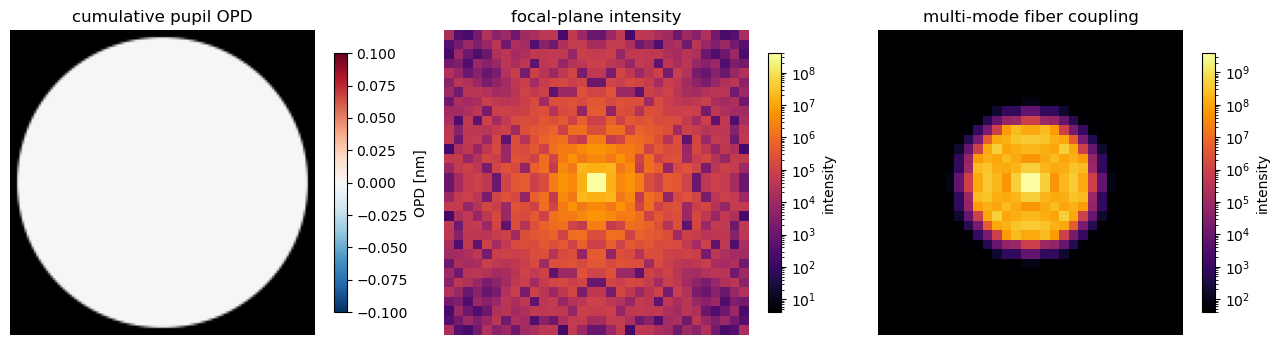

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from telescope_sim import TelescopeSim
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

config = {
    'pupil': {'resolution': 128, 'extent': 3.675},
    'aperture': {
        'type': 'segmented_circular',
        'segment_diameter': 3.5,
        'layout': 'custom',
        'positions': [[0.0, 0.0]],
    },
    'correctors': {
        'zernike_dm': {
            'type': 'zernike', 'n_modes': 10, 'zernike_diameter': 3.5,
            'starting_mode': 1, 'actuate_scale': 1e-6,
            'wavefront_role': 'actuate',
            'target_strategy': 'actuators', 'target': True,
        }
    },
    'corrector_chain': ['zernike_dm'],
    'focal_planes': {
        'filter1': {
            'type': 'physical',
            'central_lam': 6.35e-7, 'focal_extent': 5.25e-4,
            'focal_res': 32, 'focal_length': 32.5,
            'fractional_bandwidth': 0.001574803, 'num_samples': 3,
            'wavefront_total_power': 1.0,
        }
    },
    'outputs': {
        'x': {
            'tap': {
                'type': 'fiber_dual', 'focal_plane_name': 'filter1',
                'fiber': {
                    'type': 'step_index', 'core_radius': 1.0e-4,
                    'NA': 0.1, 'fiber_length': 7.4e-3, 'max_in_cache': 3,
                },
            },
            'post_processing': [],
        }
    },
}
import hcipy
from matplotlib.colors import LogNorm

sim = build(SimConfig.model_validate(config))
out = sim.sample(meas_pupil_opd=True)
stack = out['images']['x']   # (2, H, W, 1)
focal_psf, mmf_psf = stack[0, ..., 0], stack[1, ..., 0]
print('focal shape:', focal_psf.shape, ' mmf shape:', mmf_psf.shape)
print('pupil_opd RMS (nm):', 1e9 * out['pupil_opd'].std())

# Custom layout because the fiber_dual tap stacks channels [focal, mmf]
# rather than per-filter — the package's plot_opd_and_psfs helper
# assumes the per-filter stack from the intensity tap.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
opd_nm = hcipy.Field(
    1e9 * np.asarray(out['pupil_opd']), out['pupil_opd'].grid
)
plt.sca(axes[0])
im0 = hcipy.imshow_field(
    opd_nm, mask=sim.aperture.field, cmap='RdBu_r'
)
axes[0].set_title('cumulative pupil OPD')
axes[0].set_axis_off()
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='OPD [nm]')
for ax, img, title in [
    (axes[1], focal_psf, 'focal-plane intensity'),
    (axes[2], mmf_psf, 'multi-mode fiber coupling'),
]:
    vmax = float(img.max())
    vmin = vmax * 1e-8 if vmax > 0 else 1.0
    im = ax.imshow(img, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='inferno')
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='intensity')
plt.tight_layout()
plt.show()
